In [1]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

import requests

from io import StringIO

import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

In [2]:
# save the URL string to a "url" object
url = "https://esploradati.istat.it/SDMXWS/rest/data/41_983?startPeriod=2021&endPeriod=2023"

In [3]:
header = {"Accept": "application/vnd.sdmx.data+csv;version=1.0.0"}

In [4]:
# make the HTTP request
r = requests.get(url, headers=header)

In [5]:
# check the status code of HTTP request
r.status_code

200

In [6]:
df = pd.read_csv(StringIO(r.text))

In [7]:
df.head()

,DATAFLOW,FREQ,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,OBS_STATUS,NOTE_DS,NOTE_REF_AREA,NOTE_DATA_TYPE,NOTE_RESULT,NOTE_TIME_PERIOD,BASE_PER,UNIT_MEAS,UNIT_MULT
0,IT1:41_983(1.0),A,1001,KILLINJ,F,2021,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IT1:41_983(1.0),A,1001,KILLINJ,F,2022,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IT1:41_983(1.0),A,1001,KILLINJ,F,2023,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IT1:41_983(1.0),A,1001,KILLINJ,F,2024,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IT1:41_983(1.0),A,1001,KILLINJ,M,2021,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90144 entries, 0 to 90143
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   DATAFLOW          90144 non-null  str    
 1   FREQ              90144 non-null  str    
 2   REF_AREA          90144 non-null  int64  
 3   DATA_TYPE         90144 non-null  str    
 4   RESULT            90144 non-null  str    
 5   TIME_PERIOD       90144 non-null  int64  
 6   OBS_VALUE         90144 non-null  int64  
 7   OBS_STATUS        0 non-null      float64
 8   NOTE_DS           0 non-null      float64
 9   NOTE_REF_AREA     0 non-null      float64
 10  NOTE_DATA_TYPE    0 non-null      float64
 11  NOTE_RESULT       0 non-null      float64
 12  NOTE_TIME_PERIOD  0 non-null      float64
 13  BASE_PER          0 non-null      float64
 14  UNIT_MEAS         0 non-null      float64
 15  UNIT_MULT         0 non-null      float64
dtypes: float64(9), int64(3), str(4)
memory usage: 11.0 

In [9]:
df.DATAFLOW.unique()

<StringArray>
['IT1:41_983(1.0)']
Length: 1, dtype: str

In [10]:
df.FREQ.unique()

<StringArray>
['A']
Length: 1, dtype: str

In [11]:
df.REF_AREA.nunique()

7910

In [12]:
df.DATA_TYPE.unique()

<StringArray>
['KILLINJ', 'ROADACC']
Length: 2, dtype: str

In [13]:
df.RESULT.unique()

<StringArray>
['F', 'M', '9']
Length: 3, dtype: str

In [14]:
df.TIME_PERIOD.unique()

array([2021, 2022, 2023, 2024])

In [15]:
# select variables of interest
df = df[['DATAFLOW', 'FREQ', 'REF_AREA', 'DATA_TYPE', 'RESULT', 'TIME_PERIOD', 'OBS_VALUE']]

In [16]:
df = df.rename(columns=
               {'DATAFLOW': 'dataflow',
                'FREQ': 'freq',
                'REF_AREA': 'ref_area',
                'DATA_TYPE': 'data_type',
                'RESULT': 'result',
                'TIME_PERIOD': 'year',
                'OBS_VALUE': 'obs_value'   
               })

In [17]:
# upload infos about names, population and surface (sq. km) of cities, year by year, with the pd.read_csv
comuni_2021 = pd.read_csv("comuni_2021.csv", sep=";")
comuni_2022 = pd.read_csv("comuni_2022.csv", sep=";")
comuni_2023 = pd.read_csv("comuni_2023.csv", sep=";")
comuni_2024 = pd.read_csv("comuni_2024.csv", sep=";")

In [18]:
# concat four dataframes into one
df_comuni = pd.concat([comuni_2021, comuni_2022, comuni_2023, comuni_2024], ignore_index=True)

In [19]:
df_comuni.info()

<class 'pandas.DataFrame'>
RangeIndex: 31604 entries, 0 to 31603
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Codice Ripartizione geografica  31604 non-null  int64
 1   Codice Regione                  31604 non-null  int64
 2   Codice Provincia (Storico)      31604 non-null  int64
 3   Codice Provincia/Uts            31604 non-null  int64
 4   Codice Comune (alfanumerico)    31604 non-null  int64
 5   Codice Comune (numerico)        31604 non-null  int64
 6   Comune                          31600 non-null  str  
 7   Comune (dizione straniera)      496 non-null    str  
 8   Sigla automobilistica           31236 non-null  str  
 9   Capoluogo di Provincia/Uts      31604 non-null  int64
 10  Capoluogo di Regione            31604 non-null  int64
 11  Popolazione legale              31604 non-null  int64
 12  Anno Censimento                 31604 non-null  int64
 13  Superficie (

In [20]:
# select variables of interest
df_comuni = df_comuni[["Codice Comune (numerico)", "Comune", "Sigla automobilistica", "Superficie (Kmq)", "Popolazione residente", "Anno (Popolazione residente)"]]

In [21]:
# merge between first DF (df) and the second DF (df_comuni) through two variables
df_final = df.merge(
    df_comuni[['Codice Comune (numerico)', 'Comune', 'Sigla automobilistica', 'Superficie (Kmq)', 'Popolazione residente', 'Anno (Popolazione residente)']],
    how='left',
    left_on = ['ref_area', 'year'],
    right_on = ['Codice Comune (numerico)', 'Anno (Popolazione residente)']
)

In [22]:
df_final.head()

,dataflow,freq,ref_area,data_type,result,year,obs_value,Codice Comune (numerico),Comune,Sigla automobilistica,Superficie (Kmq),Popolazione residente,Anno (Popolazione residente)
0,IT1:41_983(1.0),A,1001,KILLINJ,F,2021,2,1001.0,Agliè,TO,"13,1463",2562.0,2021.0
1,IT1:41_983(1.0),A,1001,KILLINJ,F,2022,5,1001.0,Agliè,TO,"13,1463",2568.0,2022.0
2,IT1:41_983(1.0),A,1001,KILLINJ,F,2023,6,1001.0,Agliè,TO,"13,1463",2596.0,2023.0
3,IT1:41_983(1.0),A,1001,KILLINJ,F,2024,5,1001.0,Agliè,TO,"13,1463",2585.0,2024.0
4,IT1:41_983(1.0),A,1001,KILLINJ,M,2021,0,1001.0,Agliè,TO,"13,1463",2562.0,2021.0


In [23]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 90144 entries, 0 to 90143
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   dataflow                      90144 non-null  str    
 1   freq                          90144 non-null  str    
 2   ref_area                      90144 non-null  int64  
 3   data_type                     90144 non-null  str    
 4   result                        90144 non-null  str    
 5   year                          90144 non-null  int64  
 6   obs_value                     90144 non-null  int64  
 7   Codice Comune (numerico)      90141 non-null  float64
 8   Comune                        90129 non-null  str    
 9   Sigla automobilistica         89040 non-null  str    
 10  Superficie (Kmq)              90141 non-null  str    
 11  Popolazione residente         90141 non-null  float64
 12  Anno (Popolazione residente)  90141 non-null  float64
dtypes: float64(3

In [24]:
# select variables of interest
df_final = df_final[['dataflow', 'freq', 'ref_area', 'Comune', 'Sigla automobilistica', 'year', 'data_type', 'result', 'obs_value', 'Popolazione residente', 'Superficie (Kmq)']]

In [25]:
# check rows where Comune contains NaN
df_final[df_final["Comune"].isna()]

,dataflow,freq,ref_area,Comune,Sigla automobilistica,year,data_type,result,obs_value,Popolazione residente,Superficie (Kmq)
1836,IT1:41_983(1.0),A,1168,NaN,TO,2021,KILLINJ,F,11,7830.0,"24,6422"
1837,IT1:41_983(1.0),A,1168,NaN,TO,2022,KILLINJ,F,10,7790.0,"24,6422"
1838,IT1:41_983(1.0),A,1168,NaN,TO,2023,KILLINJ,F,9,7688.0,"24,6422"
1839,IT1:41_983(1.0),A,1168,NaN,TO,2024,KILLINJ,F,7,7662.0,"24,6422"
1840,IT1:41_983(1.0),A,1168,NaN,TO,2021,KILLINJ,M,0,7830.0,"24,6422"
1841,IT1:41_983(1.0),A,1168,NaN,TO,2022,KILLINJ,M,0,7790.0,"24,6422"
1842,IT1:41_983(1.0),A,1168,NaN,TO,2023,KILLINJ,M,0,7688.0,"24,6422"
1843,IT1:41_983(1.0),A,1168,NaN,TO,2024,KILLINJ,M,0,7662.0,"24,6422"
1844,IT1:41_983(1.0),A,1168,NaN,TO,2021,ROADACC,9,9,7830.0,"24,6422"
1845,IT1:41_983(1.0),A,1168,NaN,TO,2022,ROADACC,9,7,7790.0,"24,6422"


In [26]:
# drop rows where there aren't infos about Resident population and Square_kilometers
df_final = df_final.drop(index=[25739, 25742, 25745]).copy()

In [27]:
# through the resource of metadata (codelist) of REF_AREA (id: CL_ITTER107), I could find the name
# of the city with REF_AREA = 1168 / id="001168"
df_final["Comune"] = df_final["Comune"].fillna("None")

In [28]:
df_final[df_final["Sigla automobilistica"].isna()]

,dataflow,freq,ref_area,Comune,Sigla automobilistica,year,data_type,result,obs_value,Popolazione residente,Superficie (Kmq)
58053,IT1:41_983(1.0),A,63001,Acerra,NaN,2021,KILLINJ,F,99,58494.0,"54,7117"
58054,IT1:41_983(1.0),A,63001,Acerra,NaN,2022,KILLINJ,F,102,58473.0,"54,7117"
58055,IT1:41_983(1.0),A,63001,Acerra,NaN,2023,KILLINJ,F,99,58507.0,"54,7117"
58056,IT1:41_983(1.0),A,63001,Acerra,NaN,2024,KILLINJ,F,119,58676.0,"54,7117"
58057,IT1:41_983(1.0),A,63001,Acerra,NaN,2021,KILLINJ,M,4,58494.0,"54,7117"
...,...,...,...,...,...,...,...,...,...,...,...
59149,IT1:41_983(1.0),A,63092,Massa di Somma,NaN,2024,KILLINJ,M,0,4965.0,"3,0420"
59150,IT1:41_983(1.0),A,63092,Massa di Somma,NaN,2021,ROADACC,9,2,5056.0,"3,0420"
59151,IT1:41_983(1.0),A,63092,Massa di Somma,NaN,2022,ROADACC,9,2,5006.0,"3,0420"
59152,IT1:41_983(1.0),A,63092,Massa di Somma,NaN,2023,ROADACC,9,1,4985.0,"3,0420"


In [29]:
df_final.loc[df_final["Sigla automobilistica"].isna(), "Comune"].unique()

<StringArray>
[                   'Acerra',                  'Afragola',
                   'Agerola',                  'Anacapri',
                    'Arzano',                    'Bacoli',
           'Barano d'Ischia',                'Boscoreale',
              'Boscotrecase',                 'Brusciano',
                   'Caivano',                'Calvizzano',
                 'Camposano',                     'Capri',
         'Carbonara di Nola',                   'Cardito',
      'Casalnuovo di Napoli',              'Casamarciano',
        'Casamicciola Terme',                'Casandrino',
                'Casavatore',          'Casola di Napoli',
                   'Casoria',   'Castellammare di Stabia',
      'Castello di Cisterna',                   'Cercola',
                  'Cicciano',                  'Cimitile',
                 'Comiziano',                  'Crispano',
                     'Forio',            'Frattamaggiore',
              'Frattaminore',     'Giuglia

In [30]:
df_final.loc[df_final["Sigla automobilistica"].isna(), "Comune"].nunique()

92

In [31]:
# all of the cities without Provincial code belong to the province of Naples
df_final["Sigla automobilistica"] = df_final["Sigla automobilistica"].fillna("NA")

In [32]:
# change data type of Popolazione residente from float64 to int64
df_final['Popolazione residente'] = df_final['Popolazione residente'].astype('int64')

In [33]:
# check how the area (Superficie (Kmq)) of Rome is stored in the dataset
df_final[df_final['Comune']=="Roma"].head(1)

,dataflow,freq,ref_area,Comune,Sigla automobilistica,year,data_type,result,obs_value,Popolazione residente,Superficie (Kmq)
54219,IT1:41_983(1.0),A,58091,Roma,RM,2021,KILLINJ,F,13862,2749031,"1.288,1875"


In [34]:
df_final["Superficie (Kmq)"] = (
    df_final["Superficie (Kmq)"]
    .str.replace(".", "", regex=False)   # eliminate the separator of thousand
    .str.replace(",", ".", regex=False)  # converte the comma in dot
    .astype(float)
)

In [35]:
df_final['Superficie (Kmq)'] = round(df_final['Superficie (Kmq)'], 2)

In [36]:
df_final.info()

<class 'pandas.DataFrame'>
Index: 90141 entries, 0 to 90143
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dataflow               90141 non-null  str    
 1   freq                   90141 non-null  str    
 2   ref_area               90141 non-null  int64  
 3   Comune                 90141 non-null  str    
 4   Sigla automobilistica  90141 non-null  str    
 5   year                   90141 non-null  int64  
 6   data_type              90141 non-null  str    
 7   result                 90141 non-null  str    
 8   obs_value              90141 non-null  int64  
 9   Popolazione residente  90141 non-null  int64  
 10  Superficie (Kmq)       90141 non-null  float64
dtypes: float64(1), int64(4), str(6)
memory usage: 8.3 MB


In [37]:
# I want to add the extended name of province and the name of Region for all the cities
elenco_comuni = pd.read_csv("elenco_comuni_italiani.csv", encoding="latin1", sep=";")

In [38]:
elenco_comuni.columns

Index(['Codice Regione',
       'Codice dell'Unità territoriale sovracomunale \n(valida a fini statistici)',
       'Codice Provincia (Storico)(1)', 'Progressivo del Comune (2)',
       'Codice Comune formato alfanumerico',
       'Denominazione (Italiana e straniera)', 'Denominazione in italiano',
       'Denominazione altra lingua', 'Codice Ripartizione Geografica',
       'Ripartizione geografica', 'Denominazione Regione',
       'Denominazione dell'Unità territoriale sovracomunale \n(valida a fini statistici)',
       'Tipologia di Unità territoriale sovracomunale ',
       'Flag Comune capoluogo di provincia/città metropolitana/libero consorzio',
       'Sigla automobilistica', 'Codice Comune formato numerico',
       'Codice Comune numerico con 110 province (dal 2010 al 2016)',
       'Codice Comune numerico con 107 province (dal 2006 al 2009)',
       'Codice Comune numerico con 103 province (dal 1995 al 2005)',
       'Codice Catastale del comune', 'Codice NUTS1 2021',
       '

In [39]:
df_final = df_final.merge(
    elenco_comuni[["Codice Comune formato numerico", "Denominazione dell'Unità territoriale sovracomunale \n(valida a fini statistici)",
                    "Denominazione Regione"]],
    how='left',
    left_on="ref_area",
    right_on="Codice Comune formato numerico"
)

In [40]:
df_final.head()

,dataflow,freq,ref_area,Comune,Sigla automobilistica,year,data_type,result,obs_value,Popolazione residente,Superficie (Kmq),Codice Comune formato numerico,Denominazione dell'Unità territoriale sovracomunale \n(valida a fini statistici),Denominazione Regione
0,IT1:41_983(1.0),A,1001,Agliè,TO,2021,KILLINJ,F,2,2562,13.15,1001.0,Torino,Piemonte
1,IT1:41_983(1.0),A,1001,Agliè,TO,2022,KILLINJ,F,5,2568,13.15,1001.0,Torino,Piemonte
2,IT1:41_983(1.0),A,1001,Agliè,TO,2023,KILLINJ,F,6,2596,13.15,1001.0,Torino,Piemonte
3,IT1:41_983(1.0),A,1001,Agliè,TO,2024,KILLINJ,F,5,2585,13.15,1001.0,Torino,Piemonte
4,IT1:41_983(1.0),A,1001,Agliè,TO,2021,KILLINJ,M,0,2562,13.15,1001.0,Torino,Piemonte


In [41]:
df_final = df_final[['dataflow', 'freq', 'ref_area', 'Comune', 'Sigla automobilistica', 
                     "Denominazione dell'Unità territoriale sovracomunale \n(valida a fini statistici)", 
                     'Denominazione Regione', 'year', 'data_type', 'result', 'obs_value', 'Popolazione residente', 'Superficie (Kmq)']]

In [42]:
df_final = df_final.rename(columns = 
                           {'Comune': 'city',
                            'Sigla automobilistica': 'provincial_code',
                            "Denominazione dell'Unità territoriale sovracomunale \n(valida a fini statistici)": 'provincial_name',
                            'Denominazione Regione': 'region_name',
                            'Popolazione residente': 'resident_pop',
                            'Superficie (Kmq)': 'square_km'
                            })

In [43]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 90141 entries, 0 to 90140
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dataflow         90141 non-null  str    
 1   freq             90141 non-null  str    
 2   ref_area         90141 non-null  int64  
 3   city             90141 non-null  str    
 4   provincial_code  90141 non-null  str    
 5   provincial_name  90033 non-null  str    
 6   region_name      90033 non-null  str    
 7   year             90141 non-null  int64  
 8   data_type        90141 non-null  str    
 9   result           90141 non-null  str    
 10  obs_value        90141 non-null  int64  
 11  resident_pop     90141 non-null  int64  
 12  square_km        90141 non-null  float64
dtypes: float64(1), int64(4), str(8)
memory usage: 8.9 MB


In [44]:
df_final.loc[df_final["provincial_name"].isna(), "city"].unique()

<StringArray>
[        'Moransengo',            'Tonengo',           'Bardello',
            'Bregano',           'Malgesso',             'Ronago',
    'Uggiate-Trevano', 'Albaredo Arnaboldi',        'Gambugliano',
            'Sovizzo',     'Alano di Piave',          'Quero Vas',
            'Carceri',  'Vighizzolo d'Este']
Length: 14, dtype: str

In [45]:
# create a dictionary for provinces
provinces = {
    "Moransengo": "Asti",
    "Tonengo": "Asti",
    "Bardello": "Varese",
    "Bregano": "Varese",
    "Malgesso": "Varese",
    "Ronago": "Como",
    "Uggiate-Trevano": "Como",
    "Albaredo Arnaboldi": "Pavia",
    "Gambugliano": "Vicenza",
    "Sovizzo": "Vicenza",
    "Alano di Piave": "Belluno",
    "Quero Vas": "Belluno",
    "Carceri": "Padova",
    "Vighizzolo d'Este": "Padova"
}

In [46]:
# # create a dictionary for regions
regions = {
    "Moransengo": "Piemonte",
    "Tonengo": "Piemonte",
    "Bardello": "Lombardia",
    "Bregano": "Lombardia",
    "Malgesso": "Lombardia",
    "Ronago": "Lombardia",
    "Uggiate-Trevano": "Lombardia",
    "Albaredo Arnaboldi": "Lombardia",
    "Gambugliano": "Veneto",
    "Sovizzo": "Veneto",
    "Alano di Piave": "Veneto",
    "Quero Vas": "Veneto",
    "Carceri": "Veneto",
    "Vighizzolo d'Este": "Veneto"
}

In [47]:
# The fillna() method is used to replace missing values (NaN or None) with user-specified values.
# The map() method is applied to pandas Series (DataFrame columns) and is used to transform existing
# values by mapping them according to a dictionary or a function.
df_final["provincial_name"] = (
    df_final["provincial_name"]
    .fillna(df_final["city"].map(provinces))
)

In [48]:
df_final["region_name"] = (
    df_final["region_name"]
    .fillna(df_final["city"].map(regions))
)

In [49]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 90141 entries, 0 to 90140
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dataflow         90141 non-null  str    
 1   freq             90141 non-null  str    
 2   ref_area         90141 non-null  int64  
 3   city             90141 non-null  str    
 4   provincial_code  90141 non-null  str    
 5   provincial_name  90141 non-null  str    
 6   region_name      90141 non-null  str    
 7   year             90141 non-null  int64  
 8   data_type        90141 non-null  str    
 9   result           90141 non-null  str    
 10  obs_value        90141 non-null  int64  
 11  resident_pop     90141 non-null  int64  
 12  square_km        90141 non-null  float64
dtypes: float64(1), int64(4), str(8)
memory usage: 8.9 MB


In [50]:
# create a specific dataframe for road accidents
accidents = df_final[df_final["data_type"] == "ROADACC"].copy()

In [51]:
accidents.info()

<class 'pandas.DataFrame'>
Index: 30047 entries, 8 to 90140
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dataflow         30047 non-null  str    
 1   freq             30047 non-null  str    
 2   ref_area         30047 non-null  int64  
 3   city             30047 non-null  str    
 4   provincial_code  30047 non-null  str    
 5   provincial_name  30047 non-null  str    
 6   region_name      30047 non-null  str    
 7   year             30047 non-null  int64  
 8   data_type        30047 non-null  str    
 9   result           30047 non-null  str    
 10  obs_value        30047 non-null  int64  
 11  resident_pop     30047 non-null  int64  
 12  square_km        30047 non-null  float64
dtypes: float64(1), int64(4), str(8)
memory usage: 3.2 MB


In [52]:
# calculate annual per capita accident ratio for 1000 inhabitants
accidents['acc_per_1000'] = round((accidents["obs_value"] / accidents["resident_pop"]) * 1000, 2)

In [53]:
# calculate annual accidents rate density per square km
accidents['acc_per_km2'] = round(accidents['obs_value'] / accidents['square_km'], 2)

In [54]:
# calculate annual population density
accidents['pop_density'] = round(accidents['resident_pop'] / accidents['square_km'], 2)

In [55]:
accidents["pop_density"] = accidents["pop_density"].round().astype(int)

In [56]:
accidents.head()

,dataflow,freq,ref_area,city,provincial_code,provincial_name,region_name,year,data_type,result,obs_value,resident_pop,square_km,acc_per_1000,acc_per_km2,pop_density
8,IT1:41_983(1.0),A,1001,Agliè,TO,Torino,Piemonte,2021,ROADACC,9,2,2562,13.15,0.78,0.15,195
9,IT1:41_983(1.0),A,1001,Agliè,TO,Torino,Piemonte,2022,ROADACC,9,3,2568,13.15,1.17,0.23,195
10,IT1:41_983(1.0),A,1001,Agliè,TO,Torino,Piemonte,2023,ROADACC,9,3,2596,13.15,1.16,0.23,197
11,IT1:41_983(1.0),A,1001,Agliè,TO,Torino,Piemonte,2024,ROADACC,9,2,2585,13.15,0.77,0.15,197
20,IT1:41_983(1.0),A,1002,Airasca,TO,Torino,Piemonte,2021,ROADACC,9,6,3660,15.74,1.64,0.38,233


In [57]:
# The agg() (aggregate) method is used to apply one or more aggregation functions to grouped data.
# It allows different aggregation functions (e.g., sum, mean, min, max, count) to be applied
# to different columns, producing a summarized DataFrame.

# After grouping the data by city, province, and region, the agg() method computes
# the total number of accidents (sum) and the average resident population (mean), over four years 2021-2024, for each city.
acc = (
    accidents.groupby(['city', 'provincial_code', 'region_name'], as_index=False)
    .agg(
     accidents_tot=("obs_value", "sum"),
     avg_pop=("resident_pop", "mean"),
     square_km=("square_km", "max"),
     avg_acc_per_1000=("acc_per_1000", "mean"),
     avg_acc_per_km2=("acc_per_km2", "mean"),
     avg_pop_density=("pop_density", "mean")
    )
)

In [58]:
acc.head()

,city,provincial_code,region_name,accidents_tot,avg_pop,square_km,avg_acc_per_1000,avg_acc_per_km2,avg_pop_density
0,Abano Terme,PD,Veneto,207,20320.000000,21.41,2.5475,2.4175,949.000000
1,Abbadia Cerreto,LO,Lombardia,0,275.666667,6.20,0.0000,0.0000,44.333333
2,Abbadia Lariana,LC,Lombardia,97,3189.750000,16.60,7.6125,1.4625,192.250000
3,Abbadia San Salvatore,SI,Toscana,18,6065.250000,58.99,0.7425,0.0750,102.750000
4,Abbasanta,OR,Sardegna,11,2580.000000,39.85,1.0675,0.0700,64.750000


In [59]:
acc.info()

<class 'pandas.DataFrame'>
RangeIndex: 7916 entries, 0 to 7915
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   city              7916 non-null   str    
 1   provincial_code   7916 non-null   str    
 2   region_name       7916 non-null   str    
 3   accidents_tot     7916 non-null   int64  
 4   avg_pop           7916 non-null   float64
 5   square_km         7916 non-null   float64
 6   avg_acc_per_1000  7916 non-null   float64
 7   avg_acc_per_km2   7916 non-null   float64
 8   avg_pop_density   7916 non-null   float64
dtypes: float64(5), int64(1), str(3)
memory usage: 556.7 KB


In [60]:
acc["avg_pop"] = acc["avg_pop"].round().astype(int)
acc["avg_acc_per_1000"] = acc["avg_acc_per_1000"].round(2)
acc["avg_acc_per_km2"] = acc["avg_acc_per_km2"].round(2)
acc["avg_pop_density"] = acc["avg_pop_density"].round().astype(int)

In [61]:
acc_top_20 = acc.sort_values('accidents_tot', ascending=False).head(20)

[Text(0.5, 1.0, 'Top 20 Cities by Total Accidents (2021–2024)'),
 Text(0.5, 0, 'Total Accidents'),
 Text(0, 0.5, 'City')]

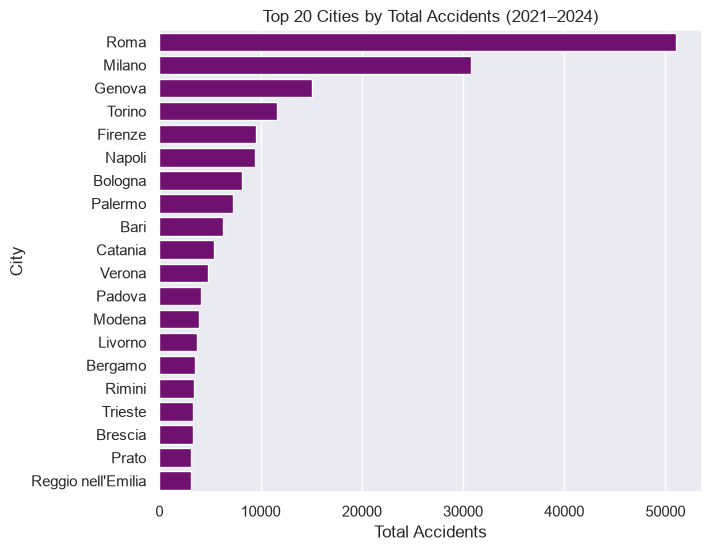

In [62]:
plt.figure(figsize=(7,6))
sns.barplot(x='accidents_tot', y='city', data=acc_top_20, errorbar=None, color='purple').set(title="Top 20 Cities by Total Accidents (2021–2024)",
                                                                                             xlabel='Total Accidents',
                                                                                             ylabel='City')

In [63]:
# first 20 cities with the highest annual per capita accident ratio
acc.sort_values('avg_acc_per_1000', ascending=False).head(10)

,city,provincial_code,region_name,accidents_tot,avg_pop,square_km,avg_acc_per_1000,avg_acc_per_km2,avg_pop_density
4090,Moncenisio,TO,Piemonte,6,46,4.50,43.30,0.44,10
913,Brienno,CO,Lombardia,23,323,8.97,17.77,0.64,36
1933,Cerignale,PC,Emilia-Romagna,6,119,30.82,16.82,0.06,4
5277,Ponte Gardena/Waidbruck,BZ,Trentino-Alto Adige/Südtirol,14,218,2.33,16.63,1.50,94
323,Argentera,CN,Piemonte,5,79,76.26,16.07,0.02,1
5685,Rocca Pia,AQ,Abruzzo,11,175,44.96,15.84,0.06,4
3664,Macra,CN,Piemonte,2,43,24.66,15.16,0.03,2
1408,Carrodano,SP,Liguria,28,471,21.86,14.92,0.32,22
519,Bard,AO,Valle d'Aosta/Vallée d'Aoste,6,105,3.03,14.57,0.50,35
2837,Forte dei Marmi,LU,Toscana,383,6816,9.19,14.05,10.42,742


In [64]:
# applicate a filter to display cities with at least 20 000 inhabitants
acc_20000 = acc[acc['avg_pop'] >= 20000].sort_values('avg_acc_per_1000', ascending=False).head(20)

In [65]:
acc_20000

,city,provincial_code,region_name,accidents_tot,avg_pop,square_km,avg_acc_per_1000,avg_acc_per_km2,avg_pop_density
641,Bergamo,BG,Lombardia,3562,119958,40.24,7.42,22.13,2981
3033,Genova,GE,Liguria,15035,562224,240.65,6.68,15.62,2336
5599,Riccione,RN,Emilia-Romagna,918,34480,17.52,6.66,13.10,1968
2745,Firenze,FI,Toscana,9526,362170,102.31,6.58,23.28,3540
5108,Pietrasanta,LU,Toscana,577,22882,42.27,6.30,3.41,542
5167,Pisa,PI,Toscana,2232,89150,185.16,6.26,3.02,482
6328,Sanremo,IM,Liguria,1327,52986,56.01,6.26,5.92,946
3350,Jesolo,VE,Veneto,664,26798,96.94,6.20,1.71,276
6549,Savona,SV,Liguria,1449,58548,65.37,6.19,5.54,896
113,Albenga,SV,Liguria,573,23497,36.59,6.10,3.92,642


[Text(0.5, 1.0, 'Top 20 Cities (Population ≥ 20,000) by Average Annual Road Accident Rate per 1,000 Inhabitants (2021–2024)'),
 Text(0.5, 0, 'Average annual road accident per 1,000 inhabitants'),
 Text(0, 0.5, 'City')]

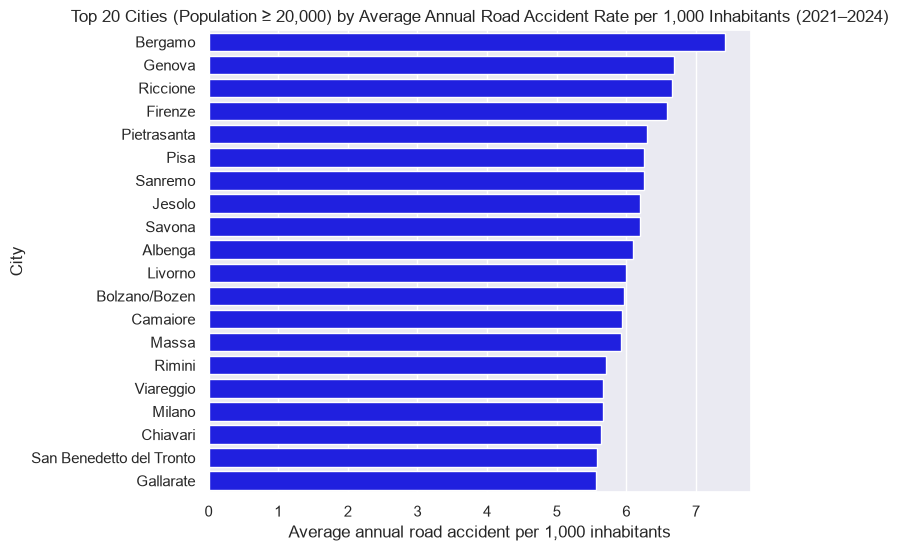

In [66]:
plt.figure(figsize=(7,6))
sns.barplot(x='avg_acc_per_1000', y='city', data=acc_20000, errorbar=None, color='blue').set(title="Top 20 Cities (Population ≥ 20,000) by Average Annual Road Accident Rate per 1,000 Inhabitants (2021–2024)",
                                                                                             xlabel='Average annual road accident per 1,000 inhabitants',
                                                                                             ylabel='City')

In [67]:
# first 20 cities with the highest annual accidents rate density per square km
acc.sort_values('avg_acc_per_km2', ascending=False).head(10)

,city,provincial_code,region_name,accidents_tot,avg_pop,square_km,avg_acc_per_1000,avg_acc_per_km2,avg_pop_density
3990,Milano,MI,Lombardia,30803,1361387,181.84,5.66,42.35,7486
2087,Cinisello Balsamo,MI,Lombardia,1196,74637,12.72,4.00,23.51,5868
2745,Firenze,FI,Toscana,9526,362170,102.31,6.58,23.28,3540
7137,Torino,TO,Piemonte,11614,850135,130.05,3.42,22.33,6538
641,Bergamo,BG,Lombardia,3562,119958,40.24,7.42,22.13,2981
2317,Cormano,MI,Lombardia,374,20520,4.47,4.55,20.92,4590
6710,Sesto San Giovanni,MI,Lombardia,947,78968,11.70,2.99,20.24,6749
4485,Napoli,NA,Campania,9423,915342,119.24,2.58,19.76,7676
2340,Corsico,MI,Lombardia,410,34545,5.37,2.97,19.09,6433
4382,Monza,MB,Lombardia,2227,122567,33.09,4.54,16.83,3704


In [68]:
# applicate a filter to display cities with at least 10 Square_kilometers
acc_10 = acc[acc['square_km'] >= 10].sort_values('avg_acc_per_km2', ascending=False).head(20)

In [69]:
acc_10

,city,provincial_code,region_name,accidents_tot,avg_pop,square_km,avg_acc_per_1000,avg_acc_per_km2,avg_pop_density
3990,Milano,MI,Lombardia,30803,1361387,181.84,5.66,42.35,7486
2087,Cinisello Balsamo,MI,Lombardia,1196,74637,12.72,4.00,23.51,5868
2745,Firenze,FI,Toscana,9526,362170,102.31,6.58,23.28,3540
7137,Torino,TO,Piemonte,11614,850135,130.05,3.42,22.33,6538
641,Bergamo,BG,Lombardia,3562,119958,40.24,7.42,22.13,2981
6710,Sesto San Giovanni,MI,Lombardia,947,78968,11.70,2.99,20.24,6749
4485,Napoli,NA,Campania,9423,915342,119.24,2.58,19.76,7676
4382,Monza,MB,Lombardia,2227,122567,33.09,4.54,16.83,3704
3033,Genova,GE,Liguria,15035,562224,240.65,6.68,15.62,2336
3461,Legnano,MI,Lombardia,1103,60287,17.70,4.57,15.58,3406


[Text(0.5, 1.0, 'Top 20 Cities (Area ≥ 10 km²) by Average Annul Road Accident Density (2021–2024)'),
 Text(0.5, 0, 'Average annual accident density (accidents/km²)')]

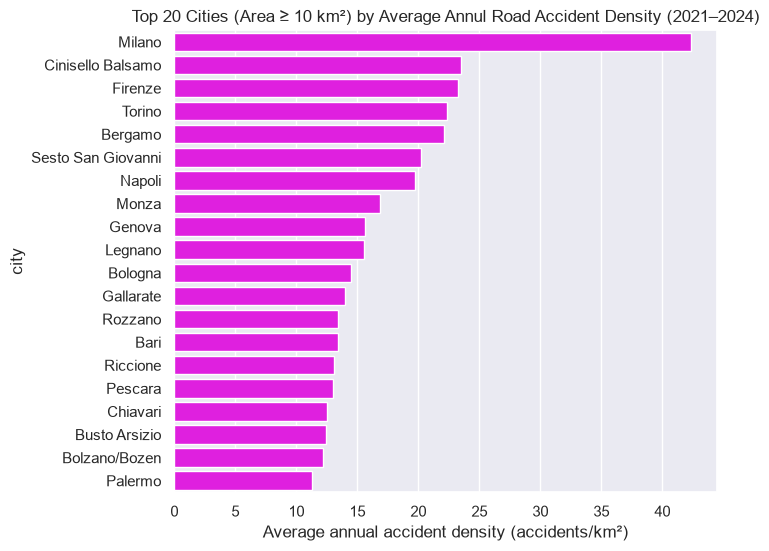

In [70]:
plt.figure(figsize=(7,6))
sns.barplot(x='avg_acc_per_km2', y='city', data=acc_10, errorbar=None, color='magenta').set(title="Top 20 Cities (Area ≥ 10 km²) by Average Annul Road Accident Density (2021–2024)",
                                                                                        xlabel="Average annual accident density (accidents/km²)")

In [71]:
# upload the number of vehicles registered in cities by year
vehicles = pd.read_csv('veicoli_2021_2024.csv')

In [72]:
vehicles.head()

,FREQ,Frequenza,REF_AREA,Territorio,DATA_TYPE,Indicatore,VEHICLE_TYPE,Tipo veicolo,TIME_PERIOD,Osservazione,OBS_STATUS,"'Stato dell""'osservazione'"
0,A,Annuale,1001,Agliè,VEHICFLEET,Parco veicolare,99,Totale,2021,2641,NaN,NaN
1,A,Annuale,1001,Agliè,VEHICFLEET,Parco veicolare,99,Totale,2022,2652,NaN,NaN
2,A,Annuale,1001,Agliè,VEHICFLEET,Parco veicolare,99,Totale,2023,2733,NaN,NaN
3,A,Annuale,1001,Agliè,VEHICFLEET,Parco veicolare,99,Totale,2024,2741,NaN,NaN
4,A,Annuale,1002,Airasca,VEHICFLEET,Parco veicolare,99,Totale,2021,3052,NaN,NaN


In [73]:
vehicles.info()

<class 'pandas.DataFrame'>
RangeIndex: 31637 entries, 0 to 31636
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   FREQ                        31637 non-null  str    
 1   Frequenza                   31637 non-null  str    
 2   REF_AREA                    31637 non-null  int64  
 3   Territorio                  31633 non-null  str    
 4   DATA_TYPE                   31637 non-null  str    
 5   Indicatore                  31637 non-null  str    
 6   VEHICLE_TYPE                31637 non-null  int64  
 7   Tipo veicolo                31637 non-null  str    
 8   TIME_PERIOD                 31637 non-null  int64  
 9   Osservazione                31637 non-null  str    
 10  OBS_STATUS                  0 non-null      float64
 11  'Stato dell"'osservazione'  0 non-null      float64
dtypes: float64(2), int64(3), str(7)
memory usage: 2.9 MB


In [74]:
df_regression = accidents.merge(
    vehicles[['REF_AREA', 'Territorio', 'TIME_PERIOD', 'Osservazione']],
    how='inner',
    left_on=['ref_area', 'city', 'year'],
    right_on=['REF_AREA', 'Territorio', 'TIME_PERIOD']
)

In [75]:
df_regression.head()

,dataflow,freq,ref_area,city,provincial_code,provincial_name,region_name,year,data_type,result,obs_value,resident_pop,square_km,acc_per_1000,acc_per_km2,pop_density,REF_AREA,Territorio,TIME_PERIOD,Osservazione
0,IT1:41_983(1.0),A,1001,Agliè,TO,Torino,Piemonte,2021,ROADACC,9,2,2562,13.15,0.78,0.15,195,1001,Agliè,2021,2641
1,IT1:41_983(1.0),A,1001,Agliè,TO,Torino,Piemonte,2022,ROADACC,9,3,2568,13.15,1.17,0.23,195,1001,Agliè,2022,2652
2,IT1:41_983(1.0),A,1001,Agliè,TO,Torino,Piemonte,2023,ROADACC,9,3,2596,13.15,1.16,0.23,197,1001,Agliè,2023,2733
3,IT1:41_983(1.0),A,1001,Agliè,TO,Torino,Piemonte,2024,ROADACC,9,2,2585,13.15,0.77,0.15,197,1001,Agliè,2024,2741
4,IT1:41_983(1.0),A,1002,Airasca,TO,Torino,Piemonte,2021,ROADACC,9,6,3660,15.74,1.64,0.38,233,1002,Airasca,2021,3052


In [76]:
df_regression.info()

<class 'pandas.DataFrame'>
RangeIndex: 28825 entries, 0 to 28824
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dataflow         28825 non-null  str    
 1   freq             28825 non-null  str    
 2   ref_area         28825 non-null  int64  
 3   city             28825 non-null  str    
 4   provincial_code  28825 non-null  str    
 5   provincial_name  28825 non-null  str    
 6   region_name      28825 non-null  str    
 7   year             28825 non-null  int64  
 8   data_type        28825 non-null  str    
 9   result           28825 non-null  str    
 10  obs_value        28825 non-null  int64  
 11  resident_pop     28825 non-null  int64  
 12  square_km        28825 non-null  float64
 13  acc_per_1000     28825 non-null  float64
 14  acc_per_km2      28825 non-null  float64
 15  pop_density      28825 non-null  int64  
 16  REF_AREA         28825 non-null  int64  
 17  Territorio       28825 

In [77]:
df_regression = df_regression[['ref_area', 'city', 'region_name', 'data_type', 'year', 'obs_value', 'resident_pop', 
                               'square_km', 'acc_per_1000', 'acc_per_km2', 'pop_density', 'Osservazione']]

In [78]:
df_regression = df_regression.rename(columns=
                                     {'Osservazione': 'vehicles_tot',
                                      'obs_value': 'accidents'})

In [79]:
df_regression.info()

<class 'pandas.DataFrame'>
RangeIndex: 28825 entries, 0 to 28824
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ref_area      28825 non-null  int64  
 1   city          28825 non-null  str    
 2   region_name   28825 non-null  str    
 3   data_type     28825 non-null  str    
 4   year          28825 non-null  int64  
 5   accidents     28825 non-null  int64  
 6   resident_pop  28825 non-null  int64  
 7   square_km     28825 non-null  float64
 8   acc_per_1000  28825 non-null  float64
 9   acc_per_km2   28825 non-null  float64
 10  pop_density   28825 non-null  int64  
 11  vehicles_tot  28825 non-null  str    
dtypes: float64(3), int64(5), str(4)
memory usage: 2.6 MB


In [80]:
df_regression['vehicles_tot'] = df_regression['vehicles_tot'].astype('int64')
df_regression['resident_pop'] = df_regression['resident_pop'].round().astype(int)

In [81]:
df_regression['motorisation_rate'] = round((df_regression['vehicles_tot'] / df_regression['resident_pop']) * 1000, 2)

In [82]:
df_regression['acc_rate_vehicles'] = round((df_regression['accidents'] / df_regression['vehicles_tot']) * 1000, 2)

In [83]:
df_regression.head()

,ref_area,city,region_name,data_type,year,accidents,resident_pop,square_km,acc_per_1000,acc_per_km2,pop_density,vehicles_tot,motorisation_rate,acc_rate_vehicles
0,1001,Agliè,Piemonte,ROADACC,2021,2,2562,13.15,0.78,0.15,195,2641,1030.84,0.76
1,1001,Agliè,Piemonte,ROADACC,2022,3,2568,13.15,1.17,0.23,195,2652,1032.71,1.13
2,1001,Agliè,Piemonte,ROADACC,2023,3,2596,13.15,1.16,0.23,197,2733,1052.77,1.10
3,1001,Agliè,Piemonte,ROADACC,2024,2,2585,13.15,0.77,0.15,197,2741,1060.35,0.73
4,1002,Airasca,Piemonte,ROADACC,2021,6,3660,15.74,1.64,0.38,233,3052,833.88,1.97


In [84]:
df_regression.info()

<class 'pandas.DataFrame'>
RangeIndex: 28825 entries, 0 to 28824
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ref_area           28825 non-null  int64  
 1   city               28825 non-null  str    
 2   region_name        28825 non-null  str    
 3   data_type          28825 non-null  str    
 4   year               28825 non-null  int64  
 5   accidents          28825 non-null  int64  
 6   resident_pop       28825 non-null  int64  
 7   square_km          28825 non-null  float64
 8   acc_per_1000       28825 non-null  float64
 9   acc_per_km2        28825 non-null  float64
 10  pop_density        28825 non-null  int64  
 11  vehicles_tot       28825 non-null  int64  
 12  motorisation_rate  28825 non-null  float64
 13  acc_rate_vehicles  28825 non-null  float64
dtypes: float64(5), int64(6), str(3)
memory usage: 3.1 MB


In [85]:
# see the correlation between variables
df_regression[['year', 'accidents', 'resident_pop', 'square_km', 'vehicles_tot', 'acc_per_1000', 'pop_density', 'acc_per_km2', 'motorisation_rate', 'acc_rate_vehicles']].corr()

,year,accidents,resident_pop,square_km,vehicles_tot,acc_per_1000,pop_density,acc_per_km2,motorisation_rate,acc_rate_vehicles
year,1.000000,0.012932,0.011547,0.020648,0.015472,0.107619,0.026881,0.048432,0.074972,0.098270
accidents,0.012932,1.000000,0.973145,0.348668,0.942015,0.106956,0.228448,0.430921,-0.031607,0.135684
resident_pop,0.011547,0.973145,1.000000,0.381979,0.973801,0.089855,0.285875,0.439812,-0.051836,0.121445
square_km,0.020648,0.348668,0.381979,1.000000,0.387494,0.071097,-0.126860,-0.034054,-0.009484,0.084115
vehicles_tot,0.015472,0.942015,0.973801,0.387494,1.000000,0.094661,0.272722,0.420692,0.079337,0.115358
acc_per_1000,0.107619,0.106956,0.089855,0.071097,0.094661,1.000000,0.050704,0.249105,0.091443,0.973343
pop_density,0.026881,0.228448,0.285875,-0.126860,0.272722,0.050704,1.000000,0.789626,-0.186323,0.101252
acc_per_km2,0.048432,0.430921,0.439812,-0.034054,0.420692,0.249105,0.789626,1.000000,-0.117927,0.311593
motorisation_rate,0.074972,-0.031607,-0.051836,-0.009484,0.079337,0.091443,-0.186323,-0.117927,1.000000,-0.037005
acc_rate_vehicles,0.098270,0.135684,0.121445,0.084115,0.115358,0.973343,0.101252,0.311593,-0.037005,1.000000


In [86]:
Y = df_regression['accidents']
X = df_regression[['resident_pop', 'square_km', 'motorisation_rate', 'year']]
X = sm.add_constant(data=X)
model_mr = sm.OLS(endog=Y,exog=X)
results_mr = model_mr.fit()

In [87]:
results_mr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              accidents   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                 1.314e+05
Date:                Mon, 03 Aug 2026   Prob (F-statistic):               0.00
Time:                        11:40:18   Log-Likelihood:            -1.5112e+05
No. Observations:               28825   AIC:                         3.023e+05
Df Residuals:                   28820   BIC:                         3.023e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              -288.1775    501.013     -0.575      0.565   -1270.186     693.832
resident_pop          0.0046   6.73e-06    676.432      0.000       0.005       0.005
square_km            -0.1051      0.006    -18.735      0.000      -0.116      -0.094
motorisation_rate     0.0215      0.002     14.171      0.000       0.019       0.025
year                  0.1274      0.248      0.514      0.607      -0.358       0.613
==============================================================================
Omnibus:                    23261.893   Durbin-Watson:                   0.600
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        675607245.159
Skew:                          -1.975   Prob(JB):                         0.00
Kurtosis:                     753.001   Cond. No.                     8.20e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.2e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [114]:
y = df_regression['accidents']
X = df_regression[['resident_pop','square_km','motorisation_rate','year']]
X = sm.add_constant(data=X)   # add a constant to the model

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [115]:
model = sm.OLS(endog=y_train,exog=X_train)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              accidents   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                 7.775e+04
Date:                Mon, 03 Aug 2026   Prob (F-statistic):               0.00
Time:                        12:00:19   Log-Likelihood:            -1.0107e+05
No. Observations:               19312   AIC:                         2.022e+05
Df Residuals:                   19307   BIC:                         2.022e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              -464.0910    605.860     -0.766      0.444   -1651.629     723.447
resident_pop          0.0046   8.72e-06    526.563      0.000       0.005       0.005
square_km            -0.1195      0.007    -17.333      0.000      -0.133      -0.106
motorisation_rate     0.0226      0.002     12.017      0.000       0.019       0.026
year                  0.2141      0.300      0.715      0.475      -0.373       0.801
==============================================================================
Omnibus:                    10382.361   Durbin-Watson:                   1.909
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        417934742.202
Skew:                           0.379   Prob(JB):                         0.00
Kurtosis:                     723.686   Cond. No.                     7.58e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.58e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [116]:
def mae(y, pred): 
    return round(np.mean(np.abs(y - pred)), 2)

In [117]:
pred_train = results.predict(X_train)

print('Naïve Training MAE:', mae(y_train, np.mean(y_train))) #naive mae
print('Training MAE:', mae(y_train, pred_train)) # mae

Naïve Training MAE: 29.08
Training MAE: 13.42


In [118]:
pred_test = results.predict(X_test)

print('Naïve Testing MAE:', mae(y_test, np.mean(y_test))) #naive mae
print('Testing MAE:', mae(y_test, pred_test)) # mae

Naïve Testing MAE: 31.79
Testing MAE: 13.68


In [121]:
# Root Mean Squared Error (RMSE)
def rmse(y, pred):
    return round(np.sqrt(np.mean((y - pred)**2)), 2)

In [122]:
print('Training RMSE:', rmse(y_train, pred_train))
print('Testing RMSE:', rmse(y_test, pred_test)) 

Training RMSE: 45.36
Testing RMSE: 46.71


In [88]:
acc_rate_vehicles = (
    df_regression.groupby(['city', 'region_name'], as_index=False)
    .agg(
     accidents_tot=("accidents", "sum"),
     avg_pop=("resident_pop", "mean"),
     square_km=("square_km", "max"),
     avg_vehicles=("vehicles_tot", "mean"),
     avg_acc_per_1000=("acc_per_1000", "mean"),
     avg_acc_per_km2=("acc_per_km2", "mean"),
     avg_pop_density=("pop_density", "mean"),
     avg_moto_rate=("motorisation_rate", "mean"),
     avg_acc_rate_vehicles=("acc_rate_vehicles", "mean")
    )
)

In [89]:
acc_rate_vehicles["avg_pop"] = acc_rate_vehicles["avg_pop"].round().astype(int)
acc_rate_vehicles["avg_vehicles"] = acc_rate_vehicles["avg_vehicles"].round().astype(int)
acc_rate_vehicles["avg_acc_per_1000"] = acc_rate_vehicles["avg_acc_per_1000"].round(2)
acc_rate_vehicles["avg_acc_per_km2"] = acc_rate_vehicles["avg_acc_per_km2"].round(2)
acc_rate_vehicles["avg_pop_density"] = acc_rate_vehicles["avg_pop_density"].round().astype(int)
acc_rate_vehicles["avg_acc_rate_vehicles"] = acc_rate_vehicles["avg_acc_rate_vehicles"].round().astype(int)

In [90]:
acc_rate_vehicles.sort_values('avg_acc_rate_vehicles', ascending=False).head(10)

,city,region_name,accidents_tot,avg_pop,square_km,avg_vehicles,avg_acc_per_1000,avg_acc_per_km2,avg_pop_density,avg_moto_rate,avg_acc_rate_vehicles
3970,Moncenisio,Piemonte,6,46,4.50,66,43.30,0.44,10,1442.576667,31
5122,Ponte Gardena/Waidbruck,Trentino-Alto Adige/Südtirol,14,218,2.33,202,16.63,1.50,94,927.350000,18
893,Brienno,Lombardia,23,323,8.97,330,17.77,0.64,36,1023.107500,17
506,Bard,Valle d'Aosta/Vallée d'Aoste,6,105,3.03,88,14.57,0.50,35,835.920000,17
1865,Cerignale,Emilia-Romagna,6,119,30.82,116,16.82,0.06,4,972.483333,17
2458,Dorio,Lombardia,12,324,11.66,276,12.37,0.34,28,851.806667,15
2739,Forte dei Marmi,Toscana,383,6816,9.19,6986,14.05,10.42,742,1025.170000,14
1374,Carrodano,Liguria,28,471,21.86,516,14.92,0.32,22,1096.117500,14
315,Argentera,Piemonte,5,79,76.26,89,16.07,0.02,1,1134.160000,14
7082,Vadena/Pfatten,Trentino-Alto Adige/Südtirol,49,1097,13.66,965,11.16,0.90,80,879.717500,13


In [91]:
acc_rate_vehicles_top_20 = acc_rate_vehicles[acc_rate_vehicles['avg_pop'] >= 20000].sort_values('avg_acc_rate_vehicles', ascending=False).head(20)

[Text(0.5, 1.0, 'Top 20 Cities (Population ≥ 20,000) by Average Annual Road Accident Rate per 1,000 Vehicles (2021–2024)'),
 Text(0.5, 0, 'Average annual road accident per 1,000 vehicles'),
 Text(0, 0.5, 'City')]

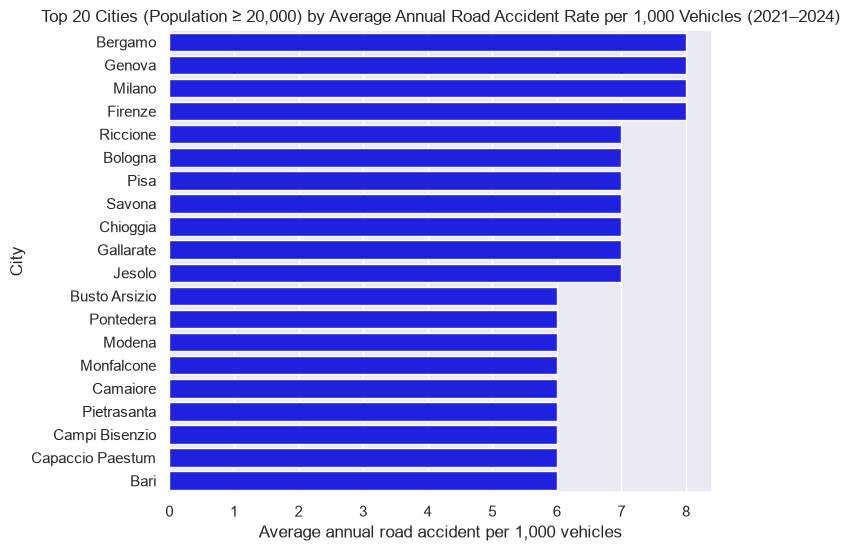

In [92]:
plt.figure(figsize=(7,6))
sns.barplot(
    x='avg_acc_rate_vehicles',
    y='city',
    data=acc_rate_vehicles_top_20, 
    errorbar=None, 
    color='blue').set(
    title="Top 20 Cities (Population ≥ 20,000) by Average Annual Road Accident Rate per 1,000 Vehicles (2021–2024)",
    xlabel='Average annual road accident per 1,000 vehicles',
    ylabel='City')

In [93]:
input_dataframe = acc_rate_vehicles[
    [
        "accidents_tot",
        "avg_pop",
        "avg_vehicles",
        "avg_acc_per_1000",
        "avg_acc_per_km2",
        "avg_pop_density",
        "avg_moto_rate",
        "avg_acc_rate_vehicles"
    ]
]

In [94]:
scale_norm = MinMaxScaler()
scaled_dataframe = pd.DataFrame(scale_norm.fit_transform(input_dataframe), columns = input_dataframe.columns)

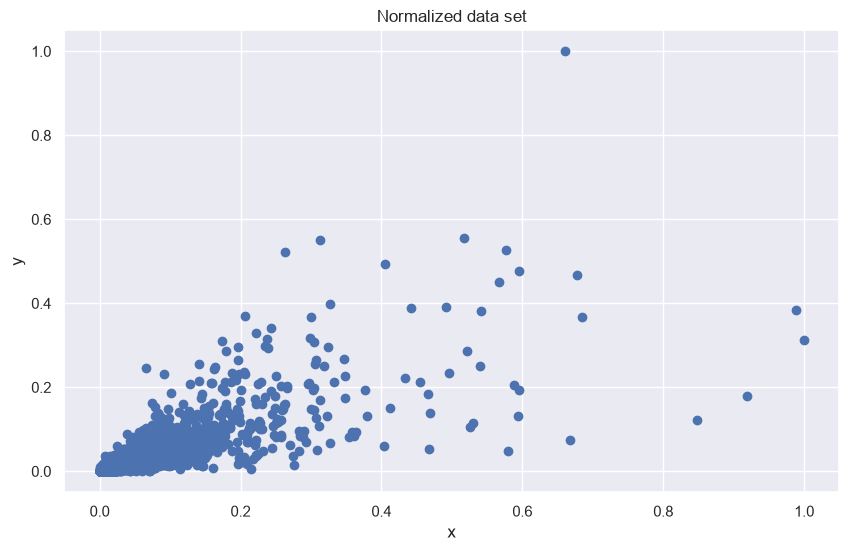

In [95]:
matplotlib.pyplot.figure(figsize=(10, 6))
matplotlib.pyplot.scatter(scaled_dataframe["avg_pop_density"], scaled_dataframe["avg_acc_per_km2"], marker="o")
matplotlib.pyplot.title('Normalized data set')
matplotlib.pyplot.xlabel('x')
matplotlib.pyplot.ylabel('y')

matplotlib.pyplot.show()

In [96]:
### Use WCSS to find a good value k
k_values = list(range(1,20))
wcss_list = []

for k in k_values:
	kmeans = KMeans(n_clusters = k, random_state=42)
	kmeans.fit(scaled_dataframe)
	wcss_list.append(kmeans.inertia_)

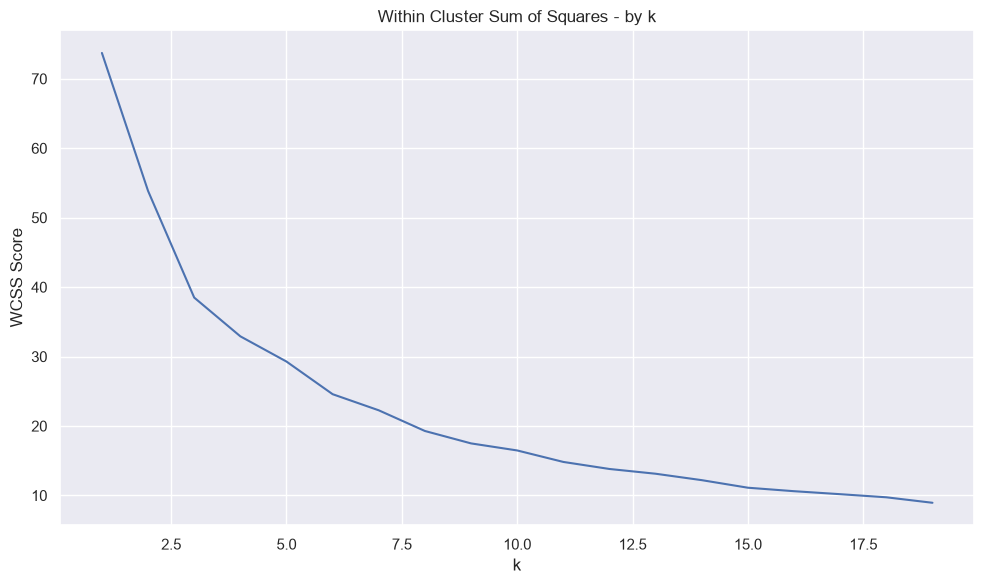

In [97]:
matplotlib.pyplot.figure(figsize=(10, 6))
matplotlib.pyplot.plot(k_values, wcss_list)
matplotlib.pyplot.title("Within Cluster Sum of Squares - by k")
matplotlib.pyplot.xlabel("k")
matplotlib.pyplot.ylabel("WCSS Score")
matplotlib.pyplot.tight_layout()
matplotlib.pyplot.show()

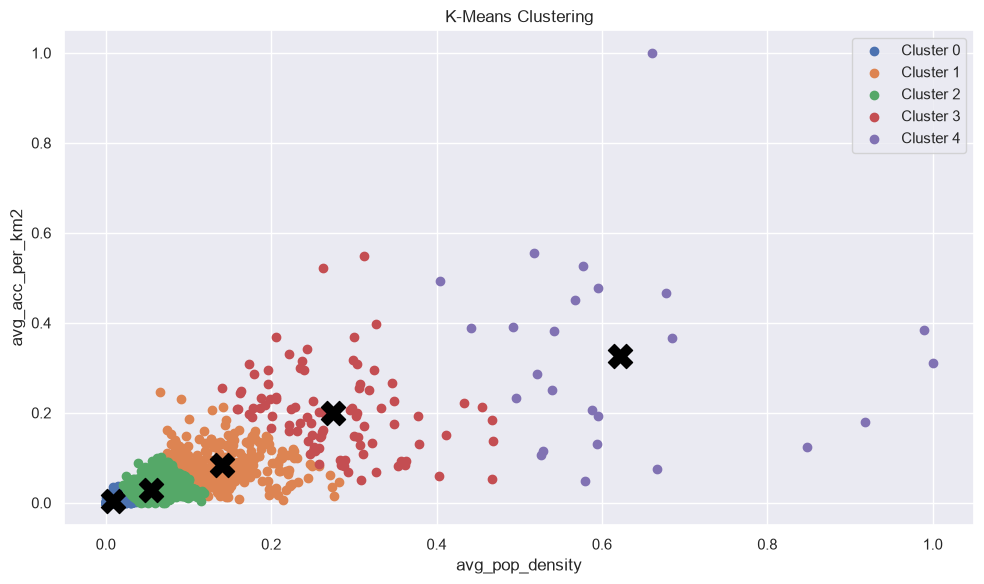

In [98]:
# Instantiate and fit the KMeans model
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(scaled_dataframe[["avg_pop_density", "avg_acc_per_km2"]])

# Add the cluster labels to the DataFrame
scaled_dataframe["cluster"] = kmeans.labels_

# Plot the clusters and centroids
centroids = kmeans.cluster_centers_
clusters = scaled_dataframe.groupby("cluster")

matplotlib.pyplot.figure(figsize=(10, 6))
for cluster, data in clusters:
    matplotlib.pyplot.scatter(data["avg_pop_density"], data["avg_acc_per_km2"], marker="o", label=f'Cluster {cluster}')
    matplotlib.pyplot.scatter(centroids[cluster, 0], centroids[cluster, 1], marker="X", color="black", s=300)

matplotlib.pyplot.xlabel("avg_pop_density")
matplotlib.pyplot.ylabel("avg_acc_per_km2")
matplotlib.pyplot.title("K-Means Clustering")
matplotlib.pyplot.legend()
matplotlib.pyplot.tight_layout()
matplotlib.pyplot.show()

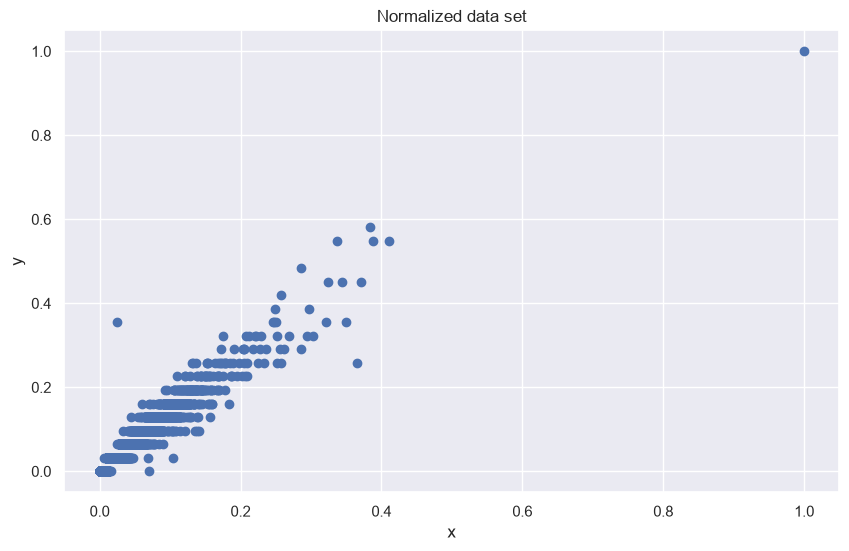

In [99]:
matplotlib.pyplot.figure(figsize=(10, 6))
matplotlib.pyplot.scatter(scaled_dataframe["avg_acc_per_1000"], scaled_dataframe["avg_acc_rate_vehicles"], marker="o")
matplotlib.pyplot.title('Normalized data set')
matplotlib.pyplot.xlabel('x')
matplotlib.pyplot.ylabel('y')

matplotlib.pyplot.show()

In [100]:
### Use WCSS to find a good value k
k_values = list(range(1,20))
wcss_list = []

for k in k_values:
	kmeans = KMeans(n_clusters = k, random_state=42)
	kmeans.fit(scaled_dataframe)
	wcss_list.append(kmeans.inertia_)

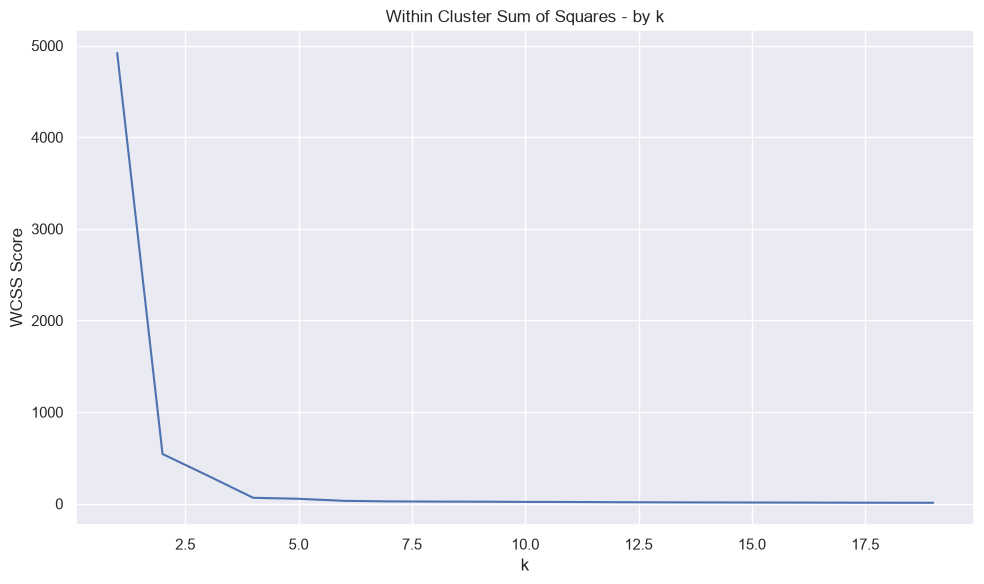

In [101]:
matplotlib.pyplot.figure(figsize=(10, 6))
matplotlib.pyplot.plot(k_values, wcss_list)
matplotlib.pyplot.title("Within Cluster Sum of Squares - by k")
matplotlib.pyplot.xlabel("k")
matplotlib.pyplot.ylabel("WCSS Score")
matplotlib.pyplot.tight_layout()
matplotlib.pyplot.show()

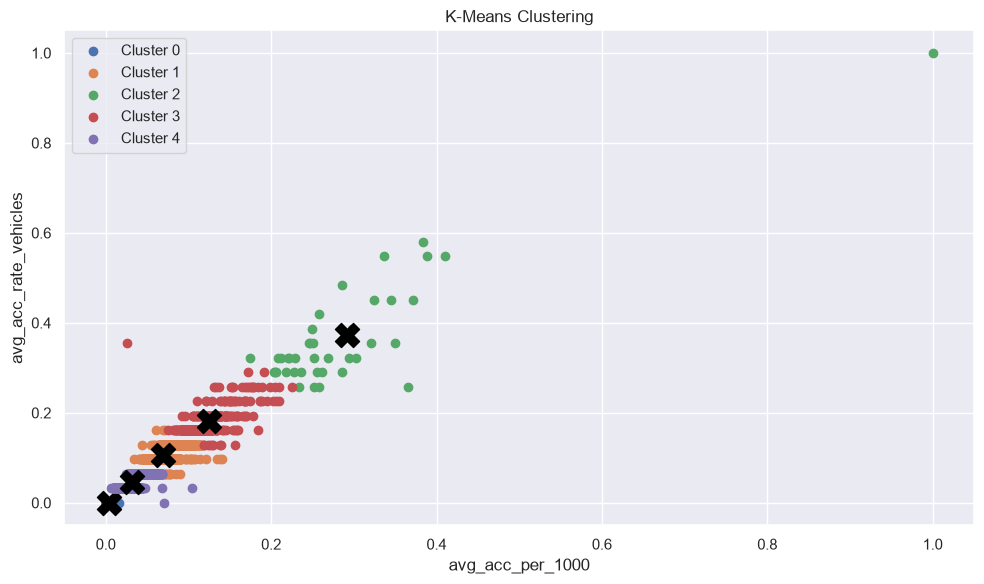

In [102]:
# Instantiate and fit the KMeans model
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(scaled_dataframe[["avg_acc_per_1000", "avg_acc_rate_vehicles"]])

# Add the cluster labels to the DataFrame
scaled_dataframe["cluster"] = kmeans.labels_

# Plot the clusters and centroids
centroids = kmeans.cluster_centers_
clusters = scaled_dataframe.groupby("cluster")

matplotlib.pyplot.figure(figsize=(10, 6))
for cluster, data in clusters:
    matplotlib.pyplot.scatter(data["avg_acc_per_1000"], data["avg_acc_rate_vehicles"], marker="o", label=f'Cluster {cluster}')
    matplotlib.pyplot.scatter(centroids[cluster, 0], centroids[cluster, 1], marker="X", color="black", s=300)

matplotlib.pyplot.xlabel("avg_acc_per_1000")
matplotlib.pyplot.ylabel("avg_acc_rate_vehicles")
matplotlib.pyplot.title("K-Means Clustering")
matplotlib.pyplot.legend()
matplotlib.pyplot.tight_layout()
matplotlib.pyplot.show()